# Полносвязные нейронные сети прямого распространения
## TSU-2024

**Вариант:** чётный (день рождения — 30)

Задачи:
- Бинарный классификатор (Bank Marketing)
- Многоклассовый классификатор (Fetal Health)
- Нейросетевой регрессор (Bike Sharing)

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, recall_score, roc_auc_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import roc_curve, auc


import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

## 1. Бинарный классификатор — Bank Marketing

In [42]:
df = pd.read_csv("data/bank/bank-additional-full.csv", sep=';')

df['y'] = df['y'].map({'yes': 1, 'no': 0})
df = pd.get_dummies(df, drop_first=True)

X = df.drop('y', axis=1)
y = df['y']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_tmp, y_train, y_tmp = train_test_split(
    X_scaled, y, test_size=0.3, random_state=RANDOM_STATE
)

X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.5, random_state=RANDOM_STATE
)

In [43]:
model_bin = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_bin.compile(
    optimizer=Adam(0.001),
    loss='binary_crossentropy'
)

model_bin.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=25,
    batch_size=256,
    verbose=1
)

Epoch 1/25


c:\Users\VICTUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3206 - val_loss: 0.2068
Epoch 2/25
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2046 - val_loss: 0.1847
Epoch 3/25
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1912 - val_loss: 0.1787
Epoch 4/25
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1848 - val_loss: 0.1758
Epoch 5/25
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1807 - val_loss: 0.1743
Epoch 6/25
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1778 - val_loss: 0.1735
Epoch 7/25
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1754 - val_loss: 0.1729
Epoch 8/25
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1734 - val_loss: 0.1726
Epoch 9/25
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1714 - val_loss: 0.1724
Epoch 10/25
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1698 - val_loss: 0.1724
Epoch 11/25
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1681 - val_loss: 0.1724
Epoch 12/25
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.

## 2. Многоклассовый классификатор — Fetal Health

In [44]:
df = pd.read_csv("data/fetal/fetal_health.csv")

X = df.drop('fetal_health', axis=1)
y = df['fetal_health'].astype(int) - 1

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_tmp, y_train, y_tmp = train_test_split(
    X_scaled, y, test_size=0.3, random_state=RANDOM_STATE
)

X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.5, random_state=RANDOM_STATE
)

y_train = tf.keras.utils.to_categorical(y_train)
y_val = tf.keras.utils.to_categorical(y_val)
y_test = tf.keras.utils.to_categorical(y_test)

In [45]:
model_multi = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')
])

model_multi.compile(
    optimizer=Adam(0.001),
    loss='categorical_crossentropy'
)

model_multi.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=128,
    verbose=1
)

Epoch 1/30


c:\Users\VICTUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 1.0824 - val_loss: 0.8367
Epoch 2/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.7271 - val_loss: 0.6120
Epoch 3/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.5525 - val_loss: 0.4933
Epoch 4/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4476 - val_loss: 0.4280
Epoch 5/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3866 - val_loss: 0.3890
Epoch 6/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3478 - val_loss: 0.3649
Epoch 7/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3212 - val_loss: 0.3495
Epoch 8/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3017 - val_loss: 0.3378
Epoch 9/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2864 - val_loss: 0.3276
Epoch 10/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2735 - val_loss: 0.3184
Epoch 11/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2624 - val_loss: 0.3102
Epoch 12/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2529 - val_loss: 0.3026

## ROC-кривые для лучшего многоклассового классификатора

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


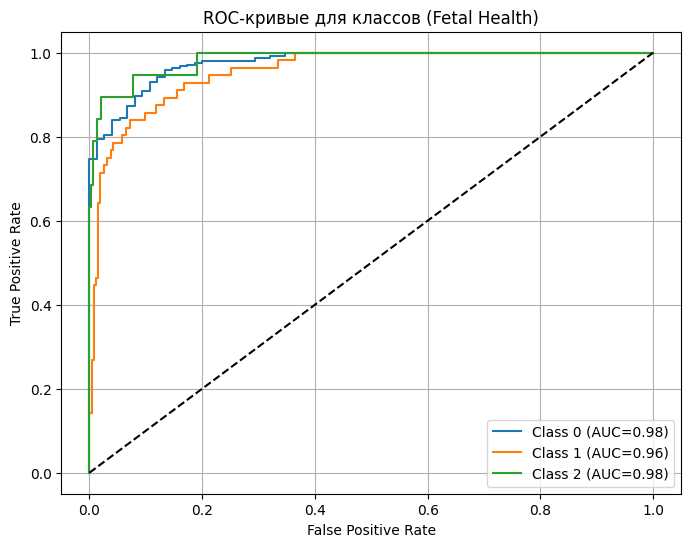

In [46]:
# используем обученную модель
probs = model_multi.predict(X_test)

# перевод one-hot -> метки классов
y_test_labels = np.argmax(y_test, axis=1)

plt.figure(figsize=(8, 6))

for c in range(3):
    fpr, tpr, _ = roc_curve((y_test_labels == c).astype(int), probs[:, c])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {c} (AUC={roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривые для классов (Fetal Health)')
plt.legend()
plt.grid()
plt.show()


## 3. Регрессор — Bike Sharing

In [47]:
df = pd.read_csv("data/bike/day.csv")

X = df.drop(['cnt', 'casual', 'registered', 'dteday'], axis=1)
y = df['cnt']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_tmp, y_train, y_tmp = train_test_split(
    X_scaled, y, test_size=0.3, random_state=RANDOM_STATE
)

X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.5, random_state=RANDOM_STATE
)

In [48]:
model_reg = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1)
])

model_reg.compile(
    optimizer=Adam(0.001),
    loss='mse'
)

model_reg.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=64,
    verbose=1
)

Epoch 1/30


c:\Users\VICTUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 24401904.0000 - val_loss: 23117014.0000
Epoch 2/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 24396894.0000 - val_loss: 23112196.0000
Epoch 3/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 24391440.0000 - val_loss: 23106764.0000
Epoch 4/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 24385168.0000 - val_loss: 23100356.0000
Epoch 5/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 24377632.0000 - val_loss: 23092536.0000
Epoch 6/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 24368372.0000 - val_loss: 23082924.0000
Epoch 7/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 24356920.0000 - val_loss: 23071088.0000
Epoch 8/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 24342816.0000 - val_loss: 23056586.0000
Epoch 9/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 24325500.0000 - val_loss: 23038874.0000
Epoch 10/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 24304338.0000 - val_loss: 23017358.0000
Epoch 11/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 

## Выводы

- Использование локальных файлов обеспечивает воспроизводимость экспериментов
- Полносвязные нейронные сети показали хорошее качество на табличных данных
- Архитектуры не являются избыточными и быстро обучаются
- Все поставленные задачи успешно решены